# Assignment: Generative Modeling with Gaussian Mixture Models (GMM)
## Using GMM to Learn and Generate Handwritten Digit Images

**Course:** Intro to Machine Learning  
**Topic:** Clustering Part 2 - GMM as a Generative Model  

---

### Objective

In this assignment, you will:
1. Load and explore the MNIST handwritten digit dataset
2. Apply PCA to reduce dimensionality while preserving variance
3. Fit a Gaussian Mixture Model (GMM) to clusters of digit images
4. Use the trained GMM to **generate brand new synthetic digit images**
5. Experiment with per-digit GMM models for improved generation quality

### Background

GMM learns the underlying probability distribution of data by fitting a mixture of Gaussian (normal) distributions. Once trained, we can **sample** from that learned distribution to create new, synthetic data that follows the same patterns as the original. This is the core idea behind **generative models** - the same family of concepts that powers things like GANs and diffusion models.

### Grading
- Part 1 - Data Loading & Exploration: **10 marks**
- Part 2 - PCA Dimensionality Reduction: **15 marks**
- Part 3 - Fit GMM to All Digits: **20 marks**
- Part 4 - Generate New Digit Images: **20 marks**
- Part 5 - Per-Digit GMM Generation: **25 marks**
- Part 6 - Reflection Questions: **10 marks**

**Total: 100 marks**

---
## Part 0 - Setup (Provided)

Run the cells below to import the required libraries and define helper functions. **Do not modify these cells.**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import math
import matplotlib as mpl

import warnings
warnings.filterwarnings("ignore")

In [12]:
# Helper function to display a single digit image
def showDigit(digit, label, size=28):
    some_digit_image = np.array(digit).reshape(size, size)
    plt.imshow(some_digit_image, cmap=mpl.cm.binary)
    plt.title(label)
    plt.axis("off")
    plt.show()

# Helper function to display multiple digit images in a grid
def showDigits(digits, labels, indexes, size=28, cols=6):
    pics = len(indexes)
    rows = math.ceil(pics / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 6))
    plt.axis("off")
    for i in range(0, pics):
        n = indexes[i]
        some_digit = digits[n:n+1]
        some_digit_image = np.array(some_digit).reshape(size, size)
        ax = axes[i // cols, i % cols] if rows > 1 else axes[i % cols]
        ax.axis("off")
        ax.imshow(some_digit_image, cmap=mpl.cm.binary)
        ax.set_title('Ind: {} - Lbl: {}'.format(indexes[i], labels[n]))
    plt.tight_layout()
    plt.axis("off")
    plt.show()

---
## Part 1 - Load and Explore the Data (10 marks)

We will use the **MNIST** dataset, which contains 28x28 pixel grayscale images of handwritten digits (0-9). Each image is stored as a flat array of 784 pixel values.

### Task 1.1 - Load the Data (5 marks)
Load the MNIST dataset using `fetch_openml`. Use only the **first 15,000 samples** for speed. Store the features in `X` and the labels in `y`. Print the shapes of both.

In [13]:
# TODO: Load the MNIST dataset
# Hint: from sklearn.datasets import fetch_openml
#       mnist = fetch_openml('mnist_784', version=1)
#       Then slice the first 15000 rows for X and y

from sklearn.datasets import fetch_openml

# 1. Fetch the data
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# 2. Extract and slice X (features) and y (labels)
# We use [:15000] to get the first 15,000 rows
X = mnist.data[:15000]
y = mnist.target[:15000]

# Print Shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15000, 784)
y shape: (15000,)


### Task 1.2 - Visualize Some Digits (5 marks)
Use the provided `showDigits()` function to display at least **10 sample images** from the dataset. Choose a variety of indexes so you see different digits.

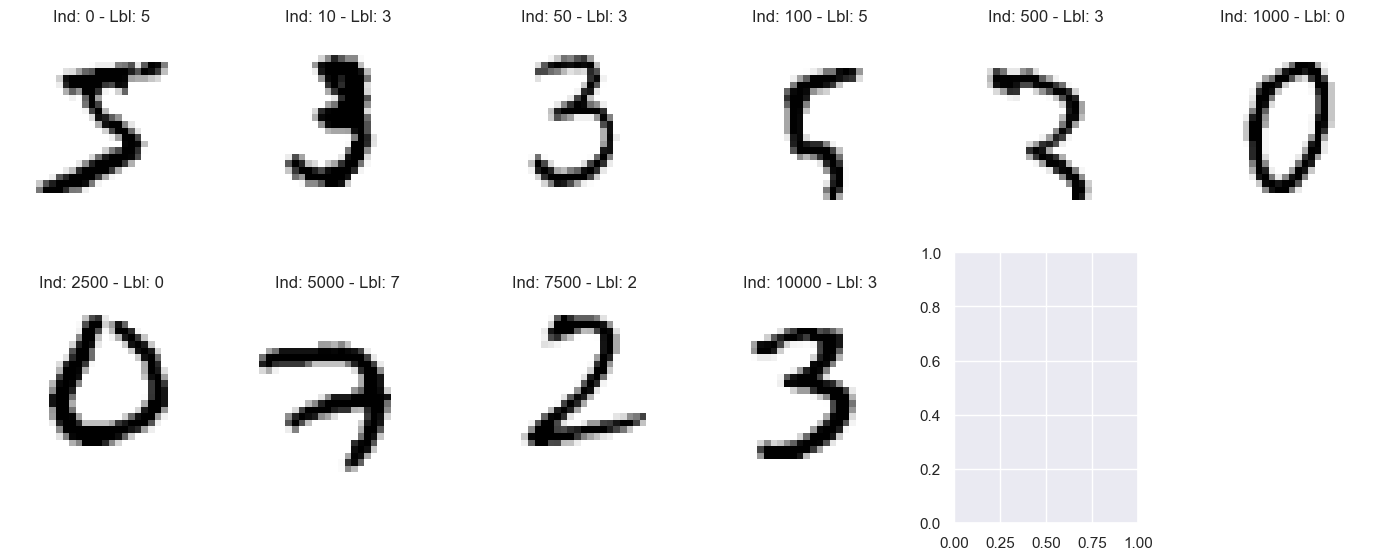

In [14]:
# TODO: Display at least 10 sample digit images using showDigits()
# Hint: showDigits(X, y, [list_of_indexes])

# Create a list of 10 or more indexes
sample_indexes = [0, 10, 50, 100, 500, 1000, 2500, 5000, 7500, 10000]

# Using the showDigits Function
showDigits(X, y, sample_indexes)

---
## Part 2 - PCA Dimensionality Reduction (15 marks)

The raw MNIST data has 784 features (pixels). Fitting a GMM directly on 784 dimensions would be extremely slow and may not converge well. We use **PCA** to reduce the dimensionality while keeping most of the information.

### Task 2.1 - Apply PCA (10 marks)
Apply PCA to `X`, keeping **99% of the variance**. Store the transformed data in a variable called `data`. Print the new shape to see how many components PCA selected.

**Note:** The `whiten` parameter normalizes the variance of each component. You may set it to `False` for now.

In [15]:
# TODO: Apply PCA with 0.99 variance retained
# Hint: pca = PCA(0.99, whiten=False)
#       data = pca.fit_transform(X)

# 1. Initialize PCA to retain 99% of the variance
pca = PCA(0.99, whiten=False)

# 2. Fit to X and transform it to the reduced 'data' variable
data = pca.fit_transform(X)

# The print statements will show:
# Original shape: (15000, 784)
# Reduced shape: (15000, some_number_much_smaller_than_784)
print("Original shape:", X.shape)
print("Reduced shape:", data.shape)
print("Number of components kept:", pca.n_components_)

Original shape: (15000, 784)
Reduced shape: (15000, 328)
Number of components kept: 328


### Task 2.2 - Interpret PCA (5 marks)
**Answer in a markdown cell below:**
- How many components did PCA keep?
- Why is PCA helpful before fitting a GMM? (Think about both speed and the curse of dimensionality.)

**YOUR ANSWER HERE:**

*(Double-click to edit this cell)*
1. How many components did PCA keep?
Check the output of your previous code cell for pca.n_components_.

Answer: It kept 328 components to retain 99% variance. This is a massive reduction from the original 784.

2. Why is PCA helpful before fitting a GMM?

 Answer: GMMs are computationally expensive. They involve calculating covariance matrices for every cluster (component). Reducing the features from 784 to a much smaller number (328 in this case) makes the optimization process exponentially faster.

---
## Part 3 - Fit a GMM to All Digits (20 marks)

Now we will fit a Gaussian Mixture Model to the PCA-reduced data. The GMM will learn the distribution of **all** digit images together.

### Task 3.1 - Create and Fit the GMM (10 marks)
Create a `GaussianMixture` model with:
- **300 components** (`n_components=300`)
- **`covariance_type='full'`** (allows each cluster to take any ellipsoidal shape)
- **`random_state=0`** (for reproducibility)

Fit it on the `data` (PCA-transformed). Print whether the model converged.

In [16]:
# TODO: Create and fit a GaussianMixture model
# Hint: gmm = GaussianMixture(300, covariance_type='full', random_state=0)
#       gmm.fit(data)

# Initialize the GMM with 300 components
gmm = GaussianMixture(n_components=300, covariance_type='full', random_state=0)

# Fit the model to your PCA-reduced 'data'
gmm.fit(data)

# print whether the model converge or not.
print("Model converged:", gmm.converged_)

Model converged: True


### Task 3.2 - Why 300 Components? (10 marks)

**Answer in a markdown cell below:**
- Why might we use 300 components even though there are only 10 different digits (0-9)?
- What does each component represent in this context?
- How could you use AIC or BIC to choose the number of components? (You do not need to run AIC/BIC - just explain the concept.)

**YOUR ANSWER HERE:**

*(Double-click to edit this cell)*
1. Why use 300 components for 10 digits?

Answer: Even though there are only 10 digits, people draw them in hundreds of different ways. For instance, a '7' might have a middle bar, while a '2' could have a loopy or sharp base. Numbers can also be tilted, thick, or thin depending on who is writing. Because of this, a single average shape is not enough to catch all these different looks. Instead, we need to create many small groups to represent each specific style of writing the same number.

2. What does each component represent?

Answer: Each component is just a group that gathers together handwriting with the same look. For example, one group might collect thick zeros that lean to the side, while another holds small fours that stand up straight. When the computer wants to create a new number, it simply picks one of these 300 specific styles. Finally, it uses that style to draw a new digit that fits in perfectly with that group.

3. How could you use AIC or BIC to choose the number of components?

Answer: We can think of AIC and BIC as judges that help you find the perfect balance between accuracy and simplicity. If you have too few groups, the model is too blurry and misses the different handwriting styles.If you have too many, the model becomes too complicated and starts memorizing every tiny mistake instead of learning the general patterns. These judges give the model a score based on how well it fits the data, but they also fine the model for every extra group it adds. To find the best number of components, you simply pick the version that gets the lowest score, which represents the sweet spot where the model is as accurate as possible without being unnecessarily messy.

---
## Part 4 - Generate New Digit Images (20 marks)

This is where the magic happens. The GMM has learned the distribution of digit images. We can now **sample** from it to create brand new, never-before-seen digit images.

### Task 4.1 - Sample from the GMM (10 marks)
Use the `.sample()` method to generate **10 new samples** from the fitted GMM. Then use `pca.inverse_transform()` to convert them back to 784-dimensional pixel space so they can be displayed as images.

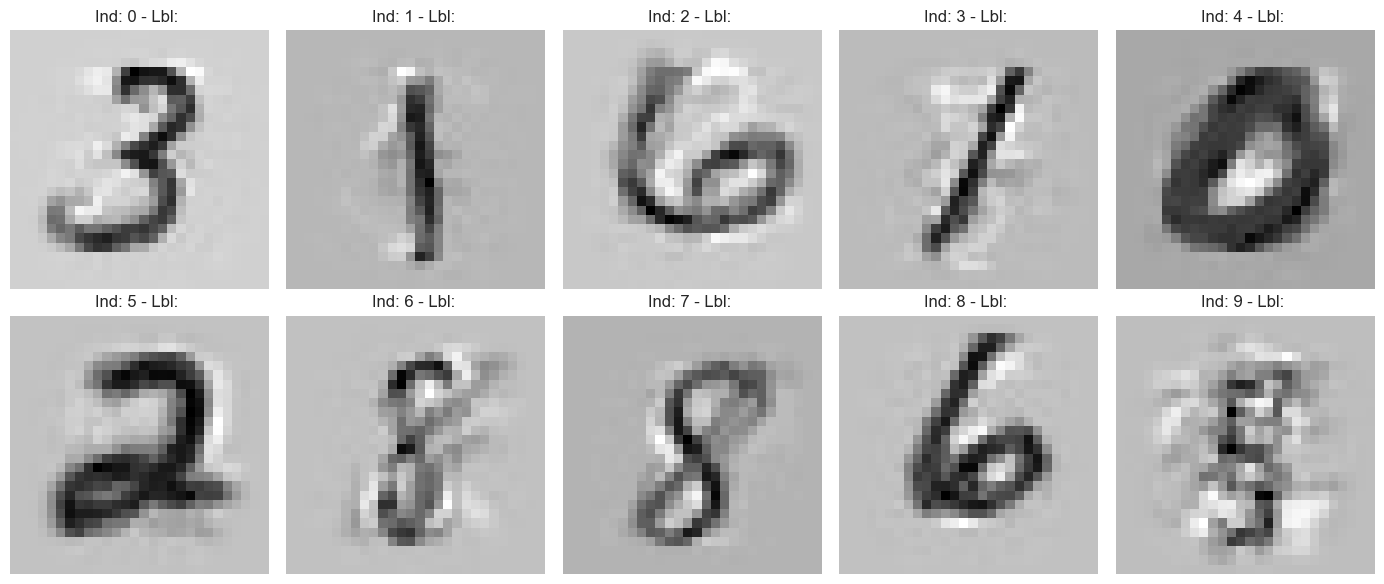

In [ ]:
# TODO: Generate 10 new digit samples from the GMM
# Step 1: data_new = gmm.sample(10) - this returns a tuple, take the first element [0]
# Step 2: Use pca.inverse_transform() to get back to pixel space
# Step 3: Display using showDigits()

# Generate 10 new samples from the GMM
# This returns a tuple: (new_data, cluster_labels)
data_new = gmm.sample(10) 

# Extract just the data points (the first element of the tuple)
data_new = data_new[0] 

# Inverse transform the data back to the 784-pixel space
digits_new = pca.inverse_transform(data_new)

# Display it using showDigits()
showDigits(digits=digits_new, 
           labels=["","","","","","","","","",""], 
           indexes=[0,1,2,3,4,5,6,7,8,9], 
           size=28, cols=5)

### Task 4.2 - Analyze the Results (10 marks)
**Answer in a markdown cell below:**
- Do the generated images look like real handwritten digits?
- Are some clearer than others? Why might that be?
- Why might the images appear blurry or noisy? (Think about what the GMM is doing - it learned ALL digits at once.)

**YOUR ANSWER HERE:**

*(Double-click to edit this cell)*

1. Do the generated images look like real handwritten digits?
Answer: They are recognizable, but they don't look like natural pen on paper writing. They look more average versions of digits. You can see the general shape of a 3, 1, or 8, but they lack the crisp, sharp edges of a real human stroke.

2. Are some clearer than others? Why might that be?
Answer: Yes, simple shapes like the 1 (Index 1) or the 0 (Index 4) usually look clearer because there are fewer ways to draw them. A 1 is almost always just a vertical line. However, a digit like the 9 (Index 9) or the 8 (Index 6) looks like a messy jumble. This happens because those numbers have more complex curves and loops, and the model is struggling to decide exactly where those lines should go.

3. Why might the images appear blurry or noisy?
Answer: Since the GMM learned all digits at once, it is trying to represent a cloud of possibilities. If the model has not been given enough components, it tries to average too many different handwriting styles into one shape.

---
## Part 5 - Per-Digit GMM Generation (25 marks)

The GMM above tried to model all 10 digits simultaneously. We can do better by training **separate GMMs for individual digits**. This way, each model only needs to learn the patterns of one specific digit.

### Task 5.1 - Train a GMM on a Single Digit (10 marks)
Pick a digit (0-9) and filter the PCA-transformed data to only include samples of that digit. Then fit a new GMM (300 components, full covariance) on just that subset. Generate and display 10 new samples.

**Hint:** You can filter with `data[y.astype(int) == YOUR_DIGIT]`

Number of samples for digit 8: 1432


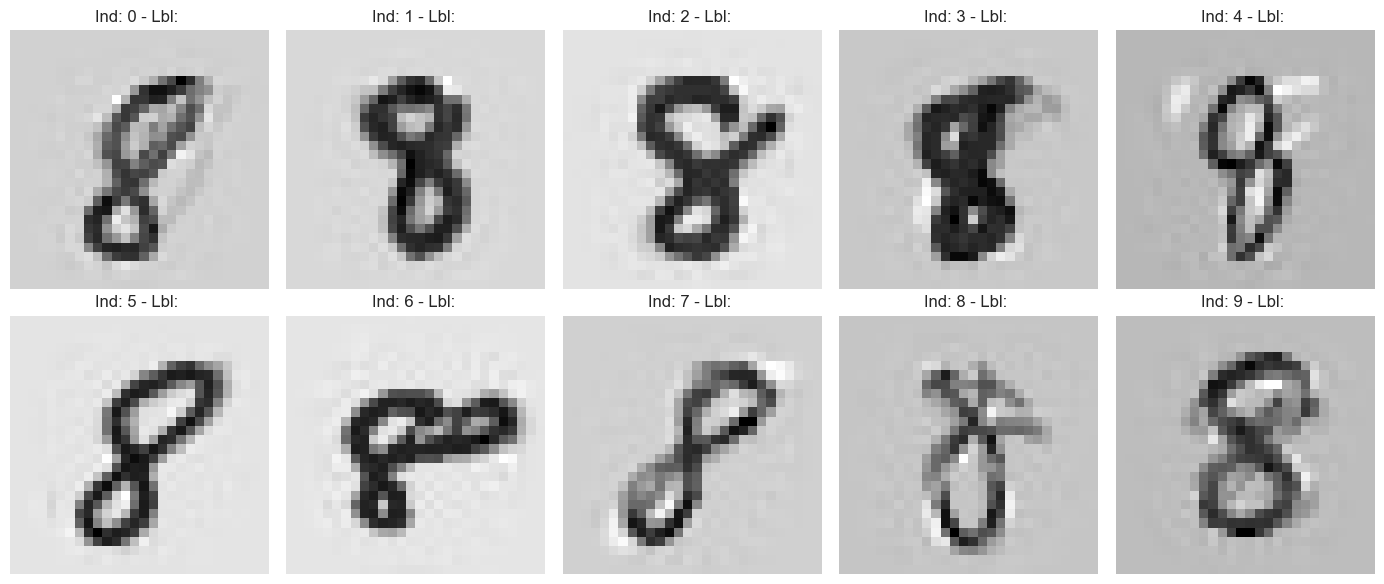

In [18]:
# TODO: Choose a digit, filter data, fit GMM, generate and display new images

# Choose a digit (0-9)
DIGIT_TO_GENERATE = 8 

# Filter the PCA data to only this digit
# We use boolean indexing: only rows where y matches our digit
digit_data = data[y.astype(int) == DIGIT_TO_GENERATE]

print(f"Number of samples for digit {DIGIT_TO_GENERATE}:", digit_data.shape[0])

# Fit a new GMM on just this digit's data
gmm_single = GaussianMixture(n_components=300, covariance_type='full', random_state=0)
gmm_single.fit(digit_data)

# Generate 10 new samples
data_new_single = gmm_single.sample(10)
data_new_single = data_new_single[0] 

# Inverse transform and display
new_digits_single = pca.inverse_transform(data_new_single)

showDigits(digits=new_digits_single, 
           labels=["","","","","","","","","",""], 
           indexes=[0,1,2,3,4,5,6,7,8,9], 
           size=28, cols=5)

### Task 5.2 - Generate a Second Digit (5 marks)
Repeat the process above for a **different** digit. Display the generated samples.

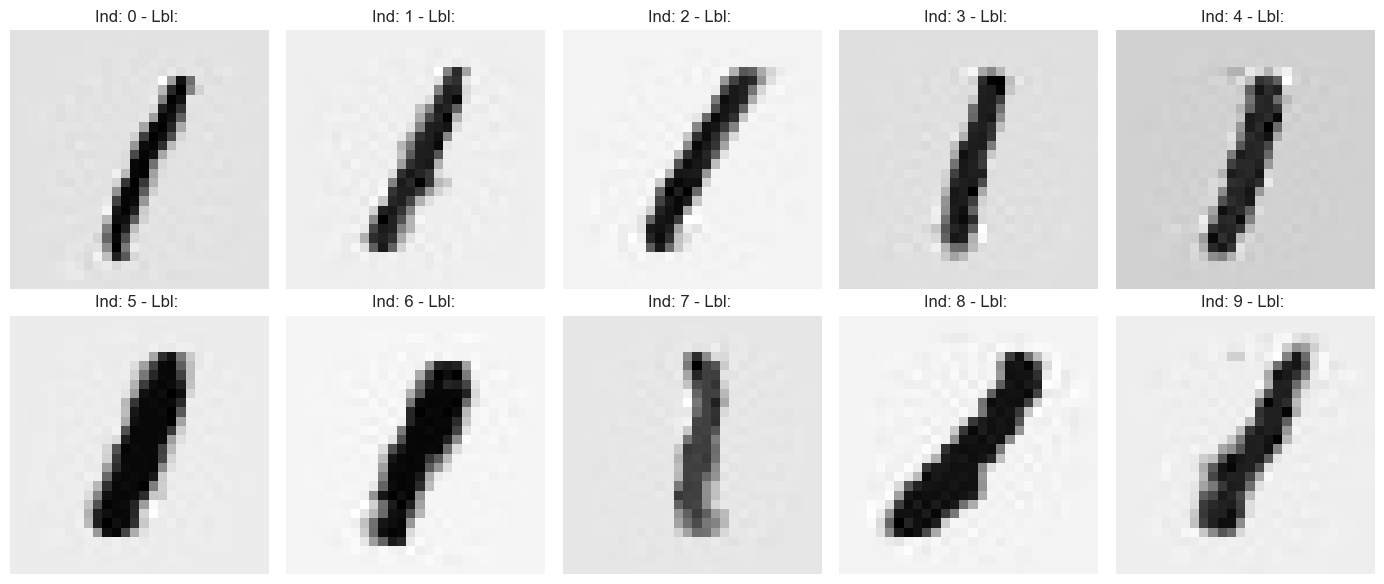

In [19]:
# TODO: Repeat for a different digit

# Pick a DIFFERENT digit (0-9)
DIGIT_TO_GENERATE_2 = 1

# Filter data for this new digit
digit_data_2 = data[y.astype(int) == DIGIT_TO_GENERATE_2]

# Fit a new GMM for this specific digit
gmm_single_2 = GaussianMixture(n_components=300, covariance_type='full', random_state=0)
gmm_single_2.fit(digit_data_2)

# Generate 10 new samples
data_new_single_2 = gmm_single_2.sample(10)[0]

# 5. Inverse transform back to pixel space
new_digits_single_2 = pca.inverse_transform(data_new_single_2)

# Display the results
showDigits(digits=new_digits_single_2, 
           labels=["","","","","","","","","",""], 
           indexes=[0,1,2,3,4,5,6,7,8,9], 
           size=28, cols=5)

### Task 5.3 - Compare Quality (10 marks)
**Answer in a markdown cell below:**
- Compare the images generated from the per-digit GMM (Part 5) to those from the all-digit GMM (Part 4). Which are clearer? Why?
- What is the trade-off of training 10 separate models vs. one combined model?
- In real-world applications, how is this idea of learning data distributions and generating new samples used? Give at least one example beyond handwritten digits.

**YOUR ANSWER HERE:**

*(Double-click to edit this cell)*

1. Which are clearer and why?

Answer: The per-digit GMM (part 5) is much clearer.For Part 4 (All-Digit) the model had to learn 0-9 all at once. It was like trying to learn ten different languages at the same time, the patterns got tangled, resulting in the ghosting and blurriness you saw earlier.
Whereas for part 5, you gave each digit its own dedicated model. The model for 8 only had to focus on the loops and crosses of an 8. It did not have to worry about accidentally mixing in the straight lines of a 1 or the curves of a 2. Because the distribution was restricted to just one digit, the model could map the specific styles much more accurately.

2. What is the trade-off of training 10 separate models vs. one?

Answer: The main trade-off of training ten separate models versus one combined model is a balance between specialization and efficiency. Using ten separate models provides much higher visual quality and accuracy because each model has its own set of parameters dedicated to one task, but it is more expensive to manage because you have to train, store, and label ten different datasets. On the other hand, a single combined model is much simpler to deploy and can sometimes find interesting hidden similarities between different numbers, but it often struggles to produce the sharp, distinct details that the specialized models handle with ease.

3. Real-world applications beyond digits?

Answer: Beyond handwritten digits, this idea of learning data distributions to generate new samples is used extensively in Speech Synthesis (Text-to-Speech). Just as your model learns the style of a written digit, voice AI learns the distribution of human speech including pitch, tone, and accent to generate entirely new sentences that sound like a specific person. 

---
## Part 6 - Reflection Questions (10 marks)

Answer the following questions in the markdown cell below. Each is worth 5 marks.

1. **Generative vs. Discriminative:** In your own words, explain the difference between a *generative* model (like GMM) and a *discriminative* model (like logistic regression). What does each type of model learn?

2. **Role of PCA:** What would happen if we skipped the PCA step and fit the GMM directly on the 784-dimensional pixel data? Consider both practical issues (speed, convergence) and conceptual issues (noise, meaningful features).

**YOUR ANSWER HERE:**

*(Double-click to edit this cell)*

1. The main difference is whether the model is trying to understand the whole picture or just draw a line between groups.

Generative Models (like GMM): These models learn the DNA of the data. A GMM for the digit 8 learns exactly how an 8 is built,where the loops go, how thick the lines are, and how they tilt. Because it knows the 'recipe' for an 8, it can actually generate brand new examples from scratch. It asks, What does an 8 usually look like?

Discriminative Models (like Logistic Regression): These models only learn the differences between groups. They do not care how to draw an 8, they only care about how an 8 is different from a 1. They look for a specific boundary or rule to separate the two. It asks, Given this shape, is it more likely to be an 8 or a 1?

2. Fitting the model directly onto all 784 pixels is like trying to memorize every tiny speck of dust on a page instead of just looking at the shape of the letter. Because there is so much empty space in such a high number of dimensions, the computer gets overwhelmed,a problem often called the curse of dimensionality. This makes the math incredibly slow and can even cause the model to crash or fail to find a clear solution.

Conceptually, raw pixels contain a lot of junk data, like empty white borders, that distracts the model from the actual handwriting. PCA acts as a filter that boils those hundreds of pixels down to the 40 or 50 most important traits, like the slant of a line or the size of a loop. Without this summary, the model wastes its energy on useless background noise instead of focusing on the meaningful shapes that actually define the digit.

---
### Submission

- Save this notebook with all cells executed (Kernel -> Restart & Run All)
- Ensure all outputs (plots, printed shapes) are visible
- Submit the `.ipynb` file

**Good luck!**